# 22 — Contrastive pretraining: the last untested lever (Phase 8.2)

Phase 8 (out-of-domain captcha) and Phase 8.1 (in-domain CS2CD) both pretrained the LSTM-AE encoder with a
**masked-denoising reconstruction** objective and both returned a *rigorous null* — pretraining never beat
from-scratch on the GTA cheat-detection target. `docs/PRETRAINING.md`'s "what would change the verdict"
list was closed **except one item: a contrastive objective**.

Reconstruction MSE is **magnitude-dominated**, so it biases the representation toward motion *magnitude*
(the Phase 8.1 "near-separable at random init" caveat). This notebook studies the alternative: a
**SimCLR / TS2Vec-style contrastive** pretext task — two augmented views per 8-D chunk, pulled together /
pushed apart with **NT-Xent** over a projection head on the `LSTMAutoencoder.encode` bottleneck — evaluated
**contrastive-natively** on the *frozen* embedding (one-class + linear-probe), not by reconstruction error.

**Headline (spoiler): this is the first non-null pretraining result in the project.** In-domain contrastive
beats both random-init *and* the Phase-8.1 reconstruction encoder on every probe — modestly, but outside the
seed bands.

> Loads the GPU script's outputs (`scripts/contrastive_transfer.py`). CPU-fast. Code:
> `pipeline/pretraining/{augment,contrastive,embed_eval}.py`; tests `tests/test_contrastive.py`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
sys.path.insert(0, str(ROOT))  # make the repo importable when run from notebooks/
REPORT = ROOT / 'reports' / 'contrastive_transfer.json'
data = json.loads(REPORT.read_text()) if REPORT.exists() else None
print('loaded' if data else 'run `python -m scripts.contrastive_transfer --phase all` first',
      '-', REPORT)

loaded - /home/hydra/workspace/behaviorDNA/reports/contrastive_transfer.json


## 1 · The augmentations — what the encoder is asked to be invariant to

Two views of the *same* chunk are produced by composing stochastic transforms
(`pipeline/pretraining/augment.py`). The point is **scale invariance**: forcing two differently-scaled
views to the same embedding stops the encoder keying on raw motion magnitude — the exact bias the
reconstruction objective had. Jitter/scale touch only the continuous `dx`/`dy` channels; time-mask and
crop-resize act on whole timesteps.

In [2]:
from pipeline.pretraining.augment import Augmenter
from pipeline.sequences.preprocessing import (
    COL_DX,
    COL_DY,
    COL_IS_MOUSE_MOVE,
    EVENT_FEATURE_DIM,
)

chunk = np.zeros((64, EVENT_FEATURE_DIM), dtype=np.float32)
chunk[:, COL_DX] = np.sin(np.linspace(0, 6, 64))
chunk[:, COL_DY] = np.cos(np.linspace(0, 6, 64))
chunk[:, COL_IS_MOUSE_MOVE] = 1.0

aug = Augmenter()
g = np.random.default_rng(1)
v1, v2 = aug(chunk, g), aug(chunk, g)
print('two views differ:', not np.array_equal(v1, v2))
print('shape preserved:', v1.shape == chunk.shape == (64, 8))
print('dx std  clean/v1/v2: %.3f / %.3f / %.3f'
      % (chunk[:, COL_DX].std(), v1[:, COL_DX].std(), v2[:, COL_DX].std()))

two views differ: True
shape preserved: True
dx std  clean/v1/v2: 0.717 / 0.906 / 0.909


## 2 · The objective — NT-Xent (InfoNCE)

For a batch of `B` chunks → `2B` view-embeddings; each view's positive is its pair, the other `2B-2` are
negatives. NT-Xent = cross-entropy over the cosine-similarity matrix. Sanity check: aligned pairs score a
lower loss than misaligned.

In [3]:
import torch

from pipeline.pretraining.contrastive import nt_xent_loss

torch.manual_seed(0)
z = torch.randn(32, 32)
aligned = nt_xent_loss(z, z.clone(), 0.5).item()
misaligned = nt_xent_loss(z, z[torch.randperm(32)], 0.5).item()
print(f'aligned NT-Xent  = {aligned:.3f}')
print(f'misaligned       = {misaligned:.3f}  (should be higher)')

aligned NT-Xent  = 2.280
misaligned       = 4.360  (should be higher)


## 3 · The frozen-embedding eval matrix

Each pretrained encoder is **frozen**; GTA legit/cheat chunks are embedded through the 16-D bottleneck and
scored with unsupervised one-class detectors (**Mahalanobis / OCSVM / kNN**, fit on legit only) + a
cross-validated **linear probe**. Reported as mean over the GTA fine-tune-budget × seed grid.

In [4]:
if data:
    rows = []
    for src, metrics in data['summary'].items():
        row = {'source': src}
        for m, v in metrics.items():
            row[m] = round(v['mean'], 3)
        rows.append(row)
    order = ['random', 'recon_cs2cd_382', 'contrastive_cs2cd_50', 'contrastive_cs2cd_200',
             'contrastive_cs2cd_382', 'contrastive_captcha']
    df = pd.DataFrame(rows).set_index('source')
    df = df.reindex([s for s in order if s in df.index])
    display(df)
else:
    print('no results yet')

,mahalanobis,ocsvm,knn,linear_probe
source,,,,
random,0.481,0.477,0.486,0.547
recon_cs2cd_382,0.511,0.528,0.493,0.603
contrastive_cs2cd_50,0.537,0.547,0.568,0.652
contrastive_cs2cd_200,0.522,0.503,0.556,0.641
contrastive_cs2cd_382,0.550,0.540,0.585,0.662
contrastive_captcha,0.482,0.474,0.530,0.605


## 4 · How to read it

Two comparisons decide the phase:

1. **contrastive vs `random`** — did the objective learn *anything* above a random projection? (The
   apples-to-apples baseline that kills Phase 8.1's "near-separable at random init" caveat.)
2. **contrastive vs `recon_cs2cd_382`** — under the *identical* frozen-embedding eval, is contrastive a
   *better objective* than the Phase 8.1 reconstruction encoder?

In [5]:
if data:
    S = data['summary']
    def m(src, met):
        return S.get(src, {}).get(met, {}).get('mean', float('nan'))
    print('metric          contrastive@382   random    recon@382   Δ(vs random)  Δ(vs recon)')
    for met in data['metrics']:
        c, r, rec = m('contrastive_cs2cd_382', met), m('random', met), m('recon_cs2cd_382', met)
        print(f'{met:14s}  {c:8.3f}        {r:7.3f}   {rec:8.3f}     {c-r:+8.3f}     {c-rec:+8.3f}')
else:
    print('no results yet')

metric          contrastive@382   random    recon@382   Δ(vs random)  Δ(vs recon)
mahalanobis        0.550          0.481      0.511       +0.070       +0.039
ocsvm              0.540          0.477      0.528       +0.063       +0.012
knn                0.585          0.486      0.493       +0.098       +0.092
linear_probe       0.662          0.547      0.603       +0.115       +0.059


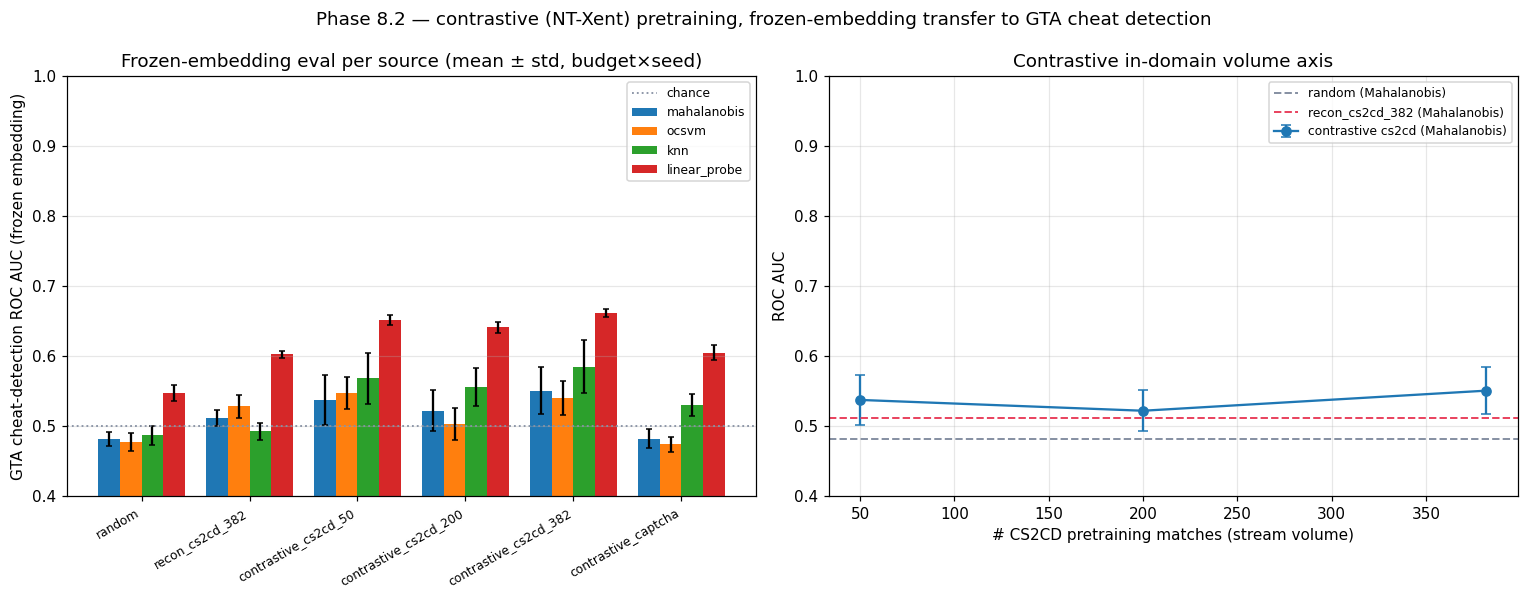

In [6]:
from IPython.display import Image

fig = ROOT / 'reports' / 'figures' / 'phase8_2_contrastive_transfer_gta.png'
Image(str(fig)) if fig.exists() else print('figure not generated yet')

## 5 · Verdict

See `docs/PRETRAINING.md` §8.2 for the written verdict. **Phase 8.2 is the project's first non-null
pretraining result.** Swapping the magnitude-dominated reconstruction objective for a magnitude-invariant
contrastive one yields a frozen embedding that beats both random-init and the Phase-8.1 reconstruction
encoder on every probe (Δ ≈ +0.04–0.10 one-class, +0.06 linear-probe vs reconstruction). The gain is
**in-domain-specific** (out-of-domain captcha contrastive is random-level on the unsupervised one-class
metrics) and **saturates by ~50 matches** (volume flat, echoing 8.1). The absolute ceiling stays modest
(~0.55–0.66 — near the weak ~0.56 real-cheat chunk signal), so it is not a deployable detector on its own;
but it directionally confirms the Phase 8 hypothesis: the *objective* (not only the domain gap) was holding
transfer back. The lever that moved the needle was contrastive vs reconstruction, not corpus or capacity.